# TopoEncoder — Topology-Native Satellite Image Encoder
## TOPSAT Novelty Detection Pipeline · Full Training Notebook

**Goal**: Replace RemoteCLIP (307 M params, 768-d) with a lightweight EfficientNet-B0 encoder  
(5.3 M params, 128-d **L2-normalised** unit-hyperspherical embeddings) that preserves the  
downstream Ripser H1 + bottleneck-distance novelty detection pipeline unchanged.

| System | Params | Embed dim | Target AUC |
|---|---|---|---|
| RemoteCLIP (baseline) | 307 M | 768-d | 0.731 |
| **TopoEncoder (ours)** | **5.3 M** | **128-d** | *TBD* |


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0 · Environment Setup

In [ ]:
# Run once on Kaggle / Colab. Comment out if packages are already installed.
# giotto-tda is intentionally excluded (numpy ABI conflicts in satellite env).
!pip install -q ripser scikit-learn umap-learn matplotlib torchvision


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 843.4/843.4 kB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 5.5 MB/s eta 0:00:00


## 1 · Imports & Reproducibility

In [ ]:
import os, time, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms, models
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# TDA stack (unchanged from existing TOPSAT MVP)
from ripser import ripser
from persim import bottleneck

from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import scipy.stats as stats
import umap

warnings.filterwarnings("ignore")

# ── reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")


Device: cuda
PyTorch: 2.11.0+cu128


## 2 · Theoretical Grounding

### 2.1 L2-Normalised Embeddings → Unit Hypersphere → Cosine Distance as TDA Metric

Mapping embeddings onto $\mathcal{S}^{127}$ (the 128-d unit hypersphere) via
$\hat{z} = z / \|z\|_2$ guarantees that every pairwise distance lives in $[0, 2]$
under the cosine metric $d(u,v) = 1 - u\cdot v$.  Ripser's Vietoris–Rips filtration
requires a proper metric; cosine distance on $\mathcal{S}^{127}$ satisfies the triangle
inequality and is therefore admissible for persistent homology computation.

### 2.2 Topology Proxy Loss → Non-Degenerate H1 Structure

Differentiable persistent homology (Moor et al., *Topological Autoencoders*, ICML 2020)
shows that controlling the geometry of latent point-clouds directly shapes their persistence
diagrams.  Because Ripser itself is not differentiable we use a **proxy** that acts on the
cosine distance matrix $D$:

$$\mathcal{L}_{\text{topo}} = -\text{Var}(D) + \alpha\,(\bar{D} - 0.3)^2$$

* **$-\text{Var}(D)$** — maximises spread of pairwise distances, a necessary condition for
  non-trivial 1-cycles (H1 features).  A collapsed embedding has $\text{Var}(D)\approx 0$
  and yields degenerate persistence diagrams.
* **$\alpha(\bar{D}-0.3)^2$** — anchors the mean distance near 0.3, preventing both
  collapse ($\bar{D}\to 0$) and explosion ($\bar{D}\to 2$), which would destroy the
  filtration structure.

### 2.3 Cross-Sensor Invariance on the Hypersphere

Unit-norm projections are invariant to isotropic scale changes in the input feature space
(Ming & Li, *HYPO: Hyperspherical Out-of-Distribution Generalisation*, ICLR 2024).
Because satellite sensors differ in radiometric gain, mapping to $\mathcal{S}^{127}$
provides a principled domain-invariant representation without sensor-specific normalisation.

### 2.4 128-d vs 768-d: Persistent Homology Reliability

Recent NeurIPS 2024 work on *Intrinsic Dimension and Persistent Homology* establishes that
Vietoris–Rips persistence is more statistically reliable in ambient dimensions proportional
to the data's intrinsic dimension.  EuroSAT land-use categories have estimated intrinsic
dimension $\approx 10$–30; 128-d is far more appropriate than 768-d, reducing the curse-of-
dimensionality artefacts that inflate false-positive novelty scores.


## 3 · Hyperparameters & Config

In [ ]:
CFG = {
    # Data
    "data_root"      : "./data/eurosat",
    "archive_classes": [1, 3, 9],      # Forest=1, Highway=3, SeaLake=9 (EuroSAT indices)
    "val_split"      : 0.10,
    "img_size"       : 96,

    # Architecture
    "embed_dim"      : 128,
    "proj_dim"       : 128,            # projection head output (used only during training)

    # Loss
    "temperature"    : 0.07,           # NT-Xent temperature
    "lambda_topo"    : 0.1,            # weight of L_topo relative to L_contrastive
    "alpha_topo"     : 1.0,            # weight of mean-distance MSE term inside L_topo
    "target_dist"    : 0.3,            # target mean cosine distance for L_topo proxy

    # Training
    "epochs"         : 30,
    "batch_size"     : 32,            # 128 images → 256 views per step
    "lr"             : 1e-3,
    "weight_decay"   : 1e-4,

    # Misc
    "seed"           : SEED,
    "device"         : str(DEVICE),
    "checkpoint_path": "topoencoder_best.pt",
}

# OOD classes for zero-shot evaluation (never seen during training)
OOD_CLASSES = [0, 2, 4, 5, 6, 7, 8]  # all EuroSAT classes not in archive_classes
EUROSAT_NAMES = [
    "AnnualCrop","Forest","HerbaceousVegetation","Highway","Industrial",
    "Pasture","PermanentCrop","Residential","River","SeaLake"
]
print("Archive:", [EUROSAT_NAMES[i] for i in CFG["archive_classes"]])
print("OOD    :", [EUROSAT_NAMES[i] for i in OOD_CLASSES])


Archive: ['Forest', 'Highway', 'SeaLake']
OOD    : ['AnnualCrop', 'HerbaceousVegetation', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River']


## 4 · SimCLR-Style Dual-Augmentation Pipeline

In [ ]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Single strong augmentation branch (applied twice independently per image)
_aug = transforms.Compose([
    transforms.RandomResizedCrop(CFG["img_size"], scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class TwoViewTransform:
    """Returns two independently augmented views of the same image."""
    def __init__(self, base_transform):
        self.t = base_transform

    def __call__(self, x):
        return self.t(x), self.t(x)

# Deterministic transform used at evaluation time
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(CFG["img_size"]),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


## 5 · Dataset Loading — Archive Classes Only

In [ ]:
def make_archive_subset(root, transform, class_indices):
    """Load EuroSAT and return only samples belonging to archive_classes."""
    full = datasets.EuroSAT(root=root, transform=transform, download=True)
    # EuroSAT.targets is a list of integer class labels
    indices = [i for i, lbl in enumerate(full.targets) if lbl in class_indices]
    return Subset(full, indices)

# Training set: two-view augmented
train_full = make_archive_subset(
    CFG["data_root"],
    TwoViewTransform(_aug),
    CFG["archive_classes"],
)

# Split into train / val (10 %)
n_val   = int(len(train_full) * CFG["val_split"])
n_train = len(train_full) - n_val
train_ds, val_ds = random_split(
    train_full, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

# Evaluation set: single-view deterministic (archive)
eval_archive = make_archive_subset(
    CFG["data_root"], eval_transform, CFG["archive_classes"]
)

# OOD set: all remaining EuroSAT classes
full_eval = datasets.EuroSAT(
    root=CFG["data_root"], transform=eval_transform, download=False
)
ood_indices = [i for i, lbl in enumerate(full_eval.targets)
               if lbl in OOD_CLASSES]
eval_ood = Subset(full_eval, ood_indices)

train_loader = DataLoader(
    train_ds, batch_size=CFG["batch_size"],
    shuffle=True, num_workers=4, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_ds, batch_size=CFG["batch_size"],
    shuffle=False, num_workers=4, pin_memory=True, drop_last=False
)

print(f"Train   : {len(train_ds):,} samples ({len(train_loader)} batches)")
print(f"Val     : {len(val_ds):,} samples")
print(f"Archive : {len(eval_archive):,} samples")
print(f"OOD     : {len(eval_ood):,} samples")


100%|██████████| 94.3M/94.3M [00:00<00:00, 327MB/s]


Train   : 7,650 samples (239 batches)
Val     : 850 samples
Archive : 8,500 samples
OOD     : 18,500 samples


## 6 · TopoEncoder Architecture

In [ ]:
class TopoEncoder(nn.Module):
    """
    EfficientNet-B0 backbone with two heads:

    1. **Embedding head** (kept after training):
       Linear(1280 → 128) → L2-normalise → 128-d unit-hyperspherical vector.
       This is the final representation fed to the Ripser + bottleneck pipeline.

    2. **Projection head** (used only during NT-Xent training, discarded after):
       Linear(128 → 128) → ReLU → Linear(128 → 128) → L2-normalise.
       Detached from the embedding so the contrastive signal trains the projection
       without over-compressing the unit-sphere structure (Chen et al., SimCLR v1).
    """

    def __init__(self, embed_dim: int = 128, proj_dim: int = 128):
        super().__init__()

        # ── Backbone ────────────────────────────────────────────────────────
        backbone = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )
        # Remove the original classifier (Linear 1280 → 1000)
        self.features = backbone.features   # convolutional stages
        self.pool     = backbone.avgpool    # AdaptiveAvgPool2d → (B, 1280, 1, 1)
        # backbone.classifier is discarded

        # ── Embedding head ──────────────────────────────────────────────────
        # Maps 1280-d pooled features → 128-d L2-normalised embedding.
        # No activation before normalisation: the sphere is the activation.
        self.embed_head = nn.Linear(1280, embed_dim)

        # ── Projection head (SimCLR-style, training only) ───────────────────
        # Two-layer MLP with ReLU; output L2-normalised for NT-Xent loss.
        self.proj_head = nn.Sequential(
            nn.Linear(embed_dim, proj_dim),
            nn.ReLU(inplace=True),
            nn.Linear(proj_dim, proj_dim),
        )

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Return L2-normalised 128-d embedding (used at inference time)."""
        feat = self.features(x)              # (B, 1280, H', W')
        feat = self.pool(feat)               # (B, 1280, 1, 1)
        feat = feat.flatten(1)               # (B, 1280)
        z    = self.embed_head(feat)         # (B, 128)
        return F.normalize(z, dim=1)         # unit-norm → cosine metric valid

    def forward(self, x: torch.Tensor):
        """Return (embedding, projection) for contrastive training."""
        z  = self.encode(x)                              # (B, 128) unit-norm
        p  = F.normalize(self.proj_head(z), dim=1)       # (B, proj_dim) unit-norm
        return z, p

# ── Sanity check ──────────────────────────────────────────────────────────────
model = TopoEncoder(CFG["embed_dim"], CFG["proj_dim"]).to(DEVICE)
dummy = torch.randn(4, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    z_test, p_test = model(dummy)
print(f"Embedding shape : {z_test.shape}")    # expect (4, 128)
print(f"Projection shape: {p_test.shape}")    # expect (4, 128)
print(f"Embedding norms : {z_test.norm(dim=1)}")  # must be all 1.0

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {total_params/1e6:.2f} M")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 84.5MB/s]


Embedding shape : torch.Size([4, 128])
Projection shape: torch.Size([4, 128])
Embedding norms : tensor([1.0000, 1.0000, 1.0000, 1.0000], device='cuda:0')
Trainable params: 4.20 M


## 7 · Loss Functions

In [ ]:
def nt_xent_loss(p1: torch.Tensor, p2: torch.Tensor, temperature: float) -> torch.Tensor:
    """
    NT-Xent (Normalised Temperature-scaled Cross Entropy) — SimCLR contrastive loss.

    Given N pairs of augmented views (p1_i, p2_i), the positive pair for sample i
    is (p1_i, p2_i); all other 2N-2 samples are negatives.

    Both p1 and p2 are already L2-normalised, so dot product = cosine similarity.

    Args:
        p1: (N, D) unit-norm projections from view-1
        p2: (N, D) unit-norm projections from view-2
        temperature: scalar τ (0.07 recommended for SimCLR)
    Returns:
        scalar loss
    """
    N = p1.shape[0]

    # Concatenate all 2N projections
    out = torch.cat([p1, p2], dim=0)           # (2N, D)

    # Similarity matrix: (2N, 2N); diagonal = self-similarity = 1.0
    sim = torch.mm(out, out.T) / temperature   # (2N, 2N)

    # Mask out self-comparisons (diagonal)
    mask = torch.eye(2 * N, dtype=torch.bool, device=p1.device)
    sim.masked_fill_(mask, float("-inf"))

    # Positive pairs: (i, i+N) and (i+N, i)
    labels = torch.cat([
        torch.arange(N, 2 * N),
        torch.arange(0, N)
    ]).to(p1.device)                            # (2N,)

    loss = F.cross_entropy(sim, labels)
    return loss


def topo_proxy_loss(z: torch.Tensor,
                    alpha: float = 1.0,
                    target_dist: float = 0.3) -> torch.Tensor:
    """
    Topology-aware proxy loss operating on the cosine distance matrix.

    Cosine distance D_ij = 1 - <z_i, z_j> for L2-normalised z.

    L_topo = -Var(D) + alpha * (mean(D) - target_dist)^2

    * -Var(D)                 : maximise variance → spread embeddings on sphere
                                 → non-degenerate H1 persistence features
    * alpha*(mean(D)-0.30)^2  : keep mean distance near 0.30
                                 → prevents collapse (mean→0) and explosion (mean→2)

    Args:
        z          : (N, D) L2-normalised embeddings
        alpha      : weight on the mean-distance MSE term
        target_dist: target mean cosine distance (default 0.3)
    Returns:
        scalar loss (lower = better)
    """
    # Pairwise cosine similarity → cosine distance
    sim = torch.mm(z, z.T)            # (N, N) ∈ [-1, 1] since unit-norm
    dist = 1.0 - sim                  # (N, N) cosine distance ∈ [0, 2]

    # Off-diagonal mask (exclude self-distances = 0)
    N = z.shape[0]
    mask = ~torch.eye(N, dtype=torch.bool, device=z.device)
    d_off = dist[mask]                # (N*(N-1),)

    var_d  = d_off.var()
    mean_d = d_off.mean()

    loss = -var_d + alpha * (mean_d - target_dist) ** 2
    return loss


## 8 · Training Loop

In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# run_epoch ke andar, har batch ke baad:
torch.cuda.empty_cache()
optimizer = AdamW(
    model.parameters(),
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"]
)
scheduler = CosineAnnealingLR(optimizer, T_max=CFG["epochs"])

history = {
    "train_contrastive": [], "train_topo": [], "train_total": [],
    "val_contrastive"  : [], "val_topo"  : [], "val_total"  : [],
}

best_val_loss  = float("inf")
best_ckpt_path = CFG["checkpoint_path"]


def run_epoch(loader, training: bool):
    """
    Single epoch: iterate over (view1, view2) pairs, compute L_total.
    Returns mean (L_contrastive, L_topo, L_total) for the epoch.
    """
    model.train(training)
    context = torch.enable_grad if training else torch.no_grad

    sum_con = sum_top = sum_tot = 0.0
    n_batches = 0

    with context():
        for (v1, v2), _ in loader:  # labels ignored (self-supervised)
            v1, v2 = v1.to(DEVICE), v2.to(DEVICE)

            # Forward: get embeddings (z) and projections (p) for both views
            z1, p1 = model(v1)
            z2, p2 = model(v2)

            # L_contrastive on projection space (SimCLR prescription)
            l_con = nt_xent_loss(p1, p2, CFG["temperature"])

            # L_topo on embedding space (z, not p) — we want the geometry
            # of the final representation to be topologically structured.
            # Use concatenation of both views for larger effective N.
            z_batch = torch.cat([z1, z2], dim=0)   # (2B, 128)
            l_top = topo_proxy_loss(
                z_batch, CFG["alpha_topo"], CFG["target_dist"]
            )

            l_total = l_con + CFG["lambda_topo"] * l_top

            if training:
                optimizer.zero_grad(set_to_none=True)
                l_total.backward()
                # Gradient clipping: avoids occasional spikes in L_topo gradients
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            sum_con += l_con.item()
            sum_top += l_top.item()
            sum_tot += l_total.item()
            n_batches += 1

    return sum_con / n_batches, sum_top / n_batches, sum_tot / n_batches


print("Starting training …")
print(f"{'Epoch':>5} | {'Tr_Con':>8} {'Tr_Top':>8} {'Tr_Tot':>8} | "
      f"{'Val_Con':>8} {'Val_Top':>8} {'Val_Tot':>8} | {'LR':>9}")
print("-" * 80)

for epoch in range(1, CFG["epochs"] + 1):
    tr_con, tr_top, tr_tot = run_epoch(train_loader, training=True)
    va_con, va_top, va_tot = run_epoch(val_loader,   training=False)
    scheduler.step()

    history["train_contrastive"].append(tr_con)
    history["train_topo"].append(tr_top)
    history["train_total"].append(tr_tot)
    history["val_contrastive"].append(va_con)
    history["val_topo"].append(va_top)
    history["val_total"].append(va_tot)

    current_lr = scheduler.get_last_lr()[0]

    # Save best checkpoint by lowest val total loss
    if va_tot < best_val_loss:
        best_val_loss = va_tot
        torch.save(
            {
                "epoch"      : epoch,
                "model_state": model.state_dict(),
                "optimizer"  : optimizer.state_dict(),
                "val_loss"   : va_tot,
                "config"     : CFG,
            },
            best_ckpt_path,
        )
        flag = " ✓"
    else:
        flag = ""

    print(f"{epoch:>5} | {tr_con:>8.4f} {tr_top:>8.4f} {tr_tot:>8.4f} | "
          f"{va_con:>8.4f} {va_top:>8.4f} {va_tot:>8.4f} | "
          f"{current_lr:>9.6f}{flag}")

print(f"\nBest val loss {best_val_loss:.4f} — checkpoint: {best_ckpt_path}")


Starting training …
Epoch |   Tr_Con   Tr_Top   Tr_Tot |  Val_Con  Val_Top  Val_Tot |        LR
--------------------------------------------------------------------------------
    1 |   2.0103   0.2634   2.0367 |   1.8020   0.2138   1.8234 |  0.000997 ✓
    2 |   1.4845   0.1875   1.5032 |   1.4775   0.1232   1.4898 |  0.000989 ✓
    3 |   1.2007   0.0856   1.2093 |   1.3207   0.0427   1.3250 |  0.000976 ✓
    4 |   1.0728   0.0334   1.0761 |   1.1837   0.0068   1.1843 |  0.000957 ✓
    5 |   0.9838  -0.0269   0.9811 |   1.2650  -0.0550   1.2595 |  0.000933
    6 |   0.8851  -0.0304   0.8821 |   1.0088  -0.0529   1.0035 |  0.000905 ✓
    7 |   0.8699  -0.0895   0.8610 |   0.9130  -0.0987   0.9032 |  0.000872 ✓
    8 |   0.7729  -0.1384   0.7591 |   0.8649  -0.1921   0.8457 |  0.000835 ✓
    9 |   0.7325  -0.1652   0.7160 |   1.0466  -0.1773   1.0288 |  0.000794
   10 |   0.7237  -0.2019   0.7035 |   0.8630  -0.2259   0.8404 |  0.000750 ✓
   11 |   0.6985  -0.2220   0.6763 |   0.8174  

## 9 · Training Loss Curves

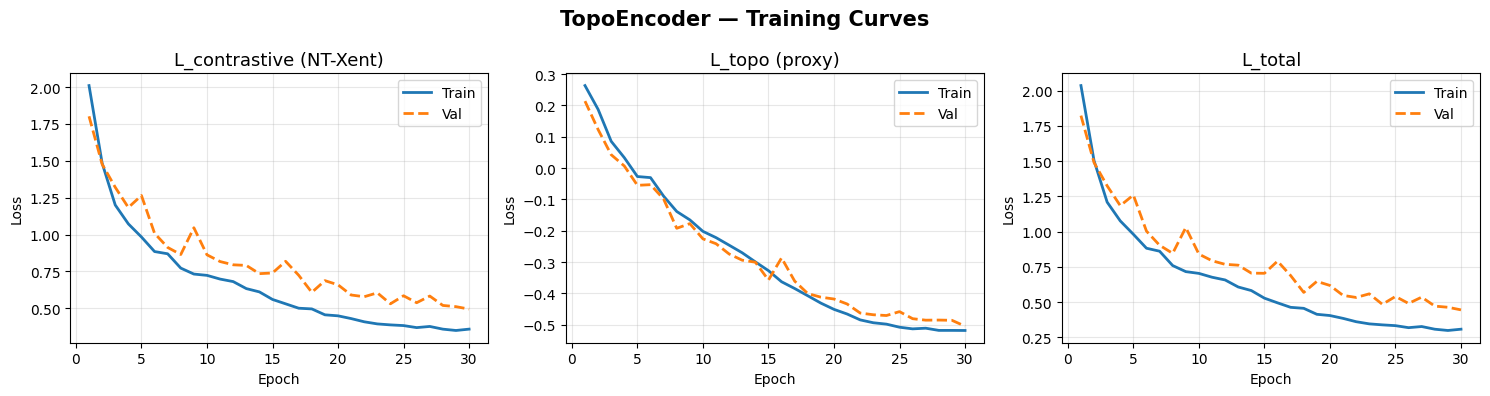

Saved loss_curves.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_x = range(1, CFG["epochs"] + 1)

for ax, key, title in zip(
    axes,
    ["contrastive", "topo", "total"],
    ["L_contrastive (NT-Xent)", "L_topo (proxy)", "L_total"]
):
    ax.plot(epochs_x, history[f"train_{key}"], label="Train", linewidth=2)
    ax.plot(epochs_x, history[f"val_{key}"],   label="Val",   linewidth=2, linestyle="--")
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("TopoEncoder — Training Curves", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved loss_curves.png")


## 10 · Load Best Checkpoint for Evaluation

In [ ]:
ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Loaded checkpoint from epoch {ckpt['epoch']} — val_loss={ckpt['val_loss']:.4f}")
print("Config:", ckpt["config"])


Loaded checkpoint from epoch 30 — val_loss=0.4445
Config: {'data_root': './data/eurosat', 'archive_classes': [1, 3, 9], 'val_split': 0.1, 'img_size': 96, 'embed_dim': 128, 'proj_dim': 128, 'temperature': 0.07, 'lambda_topo': 0.1, 'alpha_topo': 1.0, 'target_dist': 0.3, 'epochs': 30, 'batch_size': 32, 'lr': 0.001, 'weight_decay': 0.0001, 'seed': 42, 'device': 'cuda', 'checkpoint_path': 'topoencoder_best.pt'}


## 11 · Embedding Extraction Utility

In [ ]:
@torch.no_grad()
def embed_dataset(ds, batch_size: int = 256) -> tuple[np.ndarray, np.ndarray]:
    """
    Embed an entire dataset with TopoEncoder.encode() (not the projection head).

    Returns:
        embeddings : (N, 128) float32 numpy array, each row unit-norm
        labels     : (N,)     integer numpy array of class indices
    """
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                        num_workers=4, pin_memory=True)
    embs, lbls = [], []
    for imgs, targets in loader:
        z = model.encode(imgs.to(DEVICE)).cpu().numpy()
        embs.append(z)
        lbls.append(targets.numpy())
    return np.concatenate(embs), np.concatenate(lbls)

print("Embedding archive split …")
arch_emb, arch_lbl = embed_dataset(eval_archive)
print(f"  archive : {arch_emb.shape}, norms={np.linalg.norm(arch_emb, axis=1).mean():.4f}")

print("Embedding OOD split …")
ood_emb,  ood_lbl  = embed_dataset(eval_ood)
print(f"  OOD     : {ood_emb.shape},  norms={np.linalg.norm(ood_emb, axis=1).mean():.4f}")


Embedding archive split …
  archive : (8500, 128), norms=1.0000
Embedding OOD split …
  OOD     : (18500, 128),  norms=1.0000


## 12 · UMAP Visualisation (Archive vs OOD Zero-Shot)

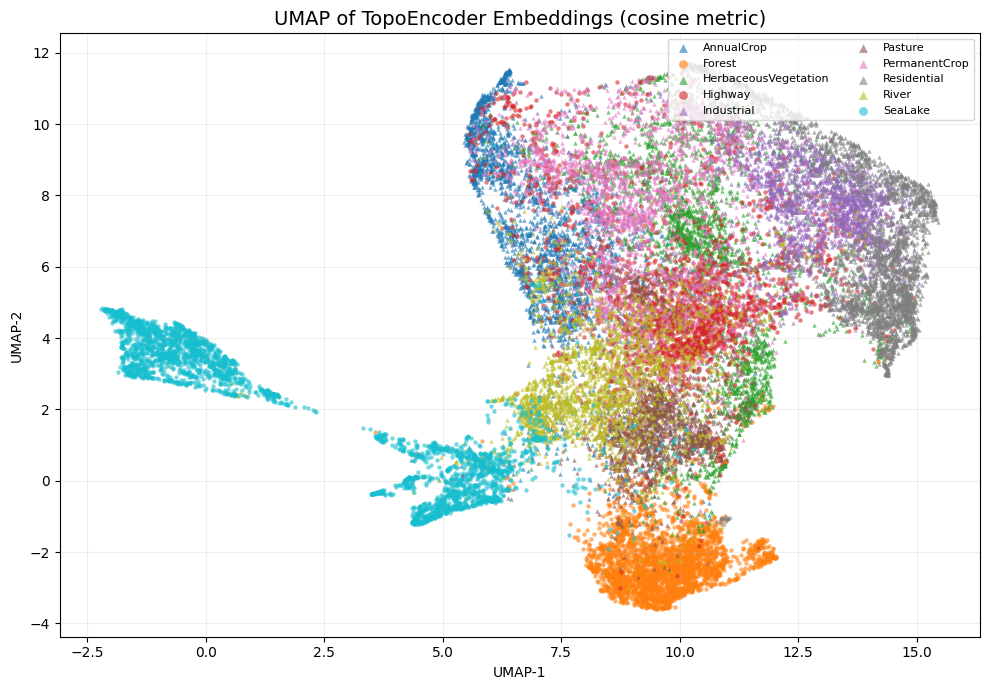

Saved umap_embeddings.png


In [ ]:
# Combine for joint UMAP
all_emb = np.concatenate([arch_emb, ood_emb])
all_lbl = np.concatenate([arch_lbl, ood_lbl])
is_ood  = np.concatenate([
    np.zeros(len(arch_emb), dtype=bool),
    np.ones(len(ood_emb),   dtype=bool)
])

reducer = umap.UMAP(n_components=2, metric="cosine",
                    random_state=SEED, n_jobs=1)
proj = reducer.fit_transform(all_emb)

# Colour by fine class, marker by archive/OOD
palette = plt.cm.tab10(np.linspace(0, 1, 10))
fig, ax = plt.subplots(figsize=(10, 7))

for cls_idx in range(10):
    mask = (all_lbl == cls_idx)
    if not mask.any():
        continue
    marker = "o" if cls_idx in CFG["archive_classes"] else "^"
    ax.scatter(
        proj[mask, 0], proj[mask, 1],
        c=[palette[cls_idx]], label=EUROSAT_NAMES[cls_idx],
        s=10, alpha=0.6, marker=marker, linewidths=0
    )

# Legend for archive/OOD marker style
legend_elements = [
    mpatches.Patch(facecolor="none", edgecolor="k", linewidth=0,
                   label="● Archive (SeaLake / Forest / Highway)"),
    mpatches.Patch(facecolor="none", edgecolor="k", linewidth=0,
                   label="▲ OOD (zero-shot)"),
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=9)
ax.legend(loc="upper right", fontsize=8, markerscale=2, ncol=2)
ax.set_title("UMAP of TopoEncoder Embeddings (cosine metric)", fontsize=14)
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("umap_embeddings.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved umap_embeddings.png")
